In [1]:
!pip install -q KoNLPy
!pip install -U -q sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 50.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import re
import time
import matplotlib.pyplot as plt

from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

okt = Okt()
results = {}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/ratings_train.txt'
TEST_PATH  = '/content/drive/MyDrive/ratings_test.txt'

train_data = pd.read_csv(TRAIN_PATH, delimiter='\t')
test_data  = pd.read_csv(TEST_PATH,  delimiter='\t')

print("전체 train shape:", train_data.shape)
print("전체 test  shape:", test_data.shape)
print("\n레이블 분포 (train):")
print(train_data['label'].value_counts())
train_data.head()

Mounted at /content/drive
전체 train shape: (150000, 3)
전체 test  shape: (50000, 3)

레이블 분포 (train):
label
0    75173
1    74827
Name: count, dtype: int64


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

print(f"전처리 후 → train: {train_data.shape}, test: {test_data.shape}")

전처리 후 → train: (149995, 3), test: (49997, 3)


In [5]:
def preprocess_base(sentence):
    sentence = re.sub(r'\\n', ' ', str(sentence))
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = sentence.strip()
    if not sentence:
        return []
    tokens = okt.morphs(sentence, stem=True)
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

In [6]:
KEEP_POS = {'Noun', 'Adjective', 'Verb', 'Adverb', 'Exclamation'}

def preprocess_pos(sentence):
    sentence = re.sub(r'\\n', ' ', str(sentence))
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = sentence.strip()
    if not sentence:
        return []
    pos_tags = okt.pos(sentence, stem=True)
    tokens   = [word for word, pos in pos_tags
                if pos in KEEP_POS and len(word) > 1]
    return tokens


In [7]:
def run_preprocessing(preprocess_fn, label=""):
    print(f"\n[전처리 시작] {label}")
    train_sents, train_labels = [], []
    test_sents,  test_labels  = [], []
    start = time.time()

    for i, (sent, lbl) in enumerate(
            zip(train_data['document'], train_data['label'])):
        if i % 10000 == 0:
            print(f"  train {i}/{len(train_data)}")
        tokens = preprocess_fn(sent)
        if tokens:
            train_sents.append(tokens)
            train_labels.append(lbl)

    for i, (sent, lbl) in enumerate(
            zip(test_data['document'], test_data['label'])):
        if i % 10000 == 0:
            print(f"  test  {i}/{len(test_data)}")
        tokens = preprocess_fn(sent)
        if tokens:
            test_sents.append(tokens)
            test_labels.append(lbl)

    print(f"  완료: {time.time()-start:.1f}s | "
          f"train {len(train_sents)}개, test {len(test_sents)}개")

    return (train_sents, np.array(train_labels),
            test_sents,  np.array(test_labels))


In [8]:
def build_baseline(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 64, input_length=max_len),  # [수정] input_length 추가
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [9]:
def build_bilstm(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 128, input_length=max_len),
        Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

In [10]:
def build_bilstm_regularized(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 64, input_length=max_len),
        Dropout(0.3),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.0)),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

In [46]:
def run_experiment(name, train_sents, test_sents,
                   train_labels, test_labels,
                   vocab_size, max_len, build_fn,
                   epochs=20, batch_size=128, callbacks=None,
                   val_split=0.2):

    print(f"\n{'='*50}")
    print(f"  실험: {name}")
    print(f"  vocab_size={vocab_size}, max_len={max_len}")
    print(f"{'='*50}")

    # Tokenizer 생성 (train으로만 사전 구축)
    tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_sents)

    train_seq = tokenizer.texts_to_sequences(train_sents)
    test_seq  = tokenizer.texts_to_sequences(test_sents)

    train_pad = pad_sequences(train_seq, maxlen=max_len,
                               padding='post', truncating='post')
    test_pad  = pad_sequences(test_seq,  maxlen=max_len,
                               padding='post', truncating='post')

    print(f"  train_pad: {train_pad.shape}, test_pad: {test_pad.shape}")

    # 토크나이저 검증 (첫 샘플 역변환)
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    decoded = ' '.join([reverse_word_index.get(i, '<pad>')
                        for i in train_pad[0] if i != 0])
    print(f"  [검증] 첫 샘플 역변환: {decoded[:80]}")

    # 모델 생성 및 학습
    model = build_fn(vocab_size, max_len)
    model.summary()

    # ✅ [수정 3] validation_split 사용
    # ❌ 기존: validation_data=(test_pad, test_labels)
    history = model.fit(
        train_pad, train_labels,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,       # [수정] train의 20%를 validation으로 분리
        callbacks=callbacks,
        verbose=1
    )

    # ✅ [수정 3] test 데이터는 별도로 평가
    test_loss, test_acc = model.evaluate(test_pad, test_labels, verbose=0)
    print(f"\n  [{name}] Test Accuracy: {test_acc*100:.2f}%")
    print(f"  [{name}] Test Loss: {test_loss:.4f}")

    best_val_acc = max(history.history['val_accuracy'])
    min_val_acc  = min(history.history['val_accuracy'])
    avg_val_acc  = np.mean(history.history['val_accuracy'])
    best_epoch   = np.argmax(history.history['val_accuracy']) + 1

    train_acc = history.history['accuracy']
    val_acc   = history.history['val_accuracy']
    gap = max(train_acc) - max(val_acc)

    val_loss     = history.history['val_loss']
    min_val_loss = min(val_loss)
    best_loss_epoch = np.argmin(val_loss) + 1

    last_train_acc = train_acc[-1]
    last_val_acc   = val_acc[-1]
    drop_from_best = best_val_acc - last_val_acc

    # results에 test_acc 저장 (기존: val_accuracy의 max)
    results[name] = round(test_acc * 100, 2)

    print(f"\n  [{name}] 최고 val_accuracy: {best_val_acc*100:.2f}%")
    print(f"  [{name}] 최저 val_accuracy: {min_val_acc*100:.2f}%")
    print(f"  [{name}] 평균 val_accuracy: {avg_val_acc*100:.2f}%")
    print(f"  [{name}] 최고 epoch: {best_epoch}")
    print(f"  [{name}] 과적합 gap: {gap*100:.2f}%")
    print(f"  [{name}] 최소 val_loss: {min_val_loss:.4f}")
    print(f"  [{name}] 최소 val_loss epoch: {best_loss_epoch}")
    print(f"  [{name}] 마지막 train_accuracy: {last_train_acc*100:.2f}%")
    print(f"  [{name}] 마지막 val_accuracy: {last_val_acc*100:.2f}%")
    print(f"  [{name}] 최고 대비 마지막 val_accuracy 하락폭: {drop_from_best*100:.2f}%")
    print(f"  [{name}] ★ Test Accuracy (최종 성능): {test_acc*100:.2f}%")

    return history, model, tokenizer

In [12]:
(train_sents_base, train_labels_base,
 test_sents_base,  test_labels_base) = run_preprocessing(
    preprocess_base, "Baseline (morphs)")

hist_base, model_base, tok_base = run_experiment(
    name         = 'Baseline',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_baseline,
    epochs       = 20
)


[전처리 시작] Baseline (morphs)
  train 0/149995
  train 10000/149995
  train 20000/149995
  train 30000/149995
  train 40000/149995
  train 50000/149995
  train 60000/149995
  train 70000/149995
  train 80000/149995
  train 90000/149995
  train 100000/149995
  train 110000/149995
  train 120000/149995
  train 130000/149995
  train 140000/149995
  test  0/49997
  test  10000/49997
  test  20000/49997
  test  30000/49997
  test  40000/49997
  완료: 715.7s | train 147737개, test 49240개

  실험: Baseline
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7973 - loss: 0.4270 - val_accuracy: 0.8238 - val_loss: 0.3895
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8385 - loss: 0.3570 - val_accuracy: 0.8246 - val_loss: 0.3856
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8592 - loss: 0.3150 - val_accuracy: 0.8294 - val_loss: 0.3927
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8848 - loss: 0.2673 - val_accuracy: 0.8178 - val_loss: 0.4418
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9049 - loss: 0.2289 - val_accuracy: 0.8107 - val_loss: 0.5111
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9156 - loss: 0.2066 - val_accuracy: 0.8039 - val_loss: 0.5556
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9213 - loss: 0.1925 - val_accuracy: 0.8013 - val_loss: 0.5855
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9276 - loss: 0.1760 - val_accuracy: 

In [13]:
(train_sents_pos, train_labels_pos,
 test_sents_pos,  test_labels_pos) = run_preprocessing(
    preprocess_pos, "Exp1 (POS filtering with Adverb)")

hist_exp1, model_exp1, tok_exp1 = run_experiment(
    name         = 'Exp1_POS',
    train_sents  = train_sents_pos,
    test_sents   = test_sents_pos,
    train_labels = train_labels_pos,
    test_labels  = test_labels_pos,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_baseline,   # 모델 동일
    epochs       = 20
)


[전처리 시작] Exp1 (POS filtering with Adverb)
  train 0/149995
  train 10000/149995
  train 20000/149995
  train 30000/149995
  train 40000/149995
  train 50000/149995
  train 60000/149995
  train 70000/149995
  train 80000/149995
  train 90000/149995
  train 100000/149995
  train 110000/149995
  train 120000/149995
  train 130000/149995
  train 140000/149995
  test  0/49997
  test  10000/49997
  test  20000/49997
  test  30000/49997
  test  40000/49997
  완료: 951.7s | train 147283개, test 49070개

  실험: Exp1_POS
  vocab_size=10000, max_len=15
  train_pad: (147283, 15), test_pad: (49070, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7938 - loss: 0.4322 - val_accuracy: 0.8154 - val_loss: 0.4071
Epoch 2/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8362 - loss: 0.3624 - val_accuracy: 0.8275 - val_loss: 0.3860
Epoch 3/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8532 - loss: 0.3246 - val_accuracy: 0.8240 - val_loss: 0.4109
Epoch 4/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8759 - loss: 0.2820 - val_accuracy: 0.8196 - val_loss: 0.4507
Epoch 5/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8969 - loss: 0.2431 - val_accuracy: 0.8132 - val_loss: 0.4685
Epoch 6/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9113 - loss: 0.2143 - val_accuracy: 0.8094 - val_loss: 0.5058
Epoch 7/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9204 - loss: 0.1952 - val_accuracy: 0.8091 - val_loss: 0.5802
Epoch 8/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9246 - loss: 0.1836 - val_accuracy: 0.

In [14]:
hist_exp2, model_exp2, tok_exp2 = run_experiment(
    name         = 'Exp2_BiLSTM',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_bilstm,
    epochs       = 20
)


  실험: Exp2_BiLSTM
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.8013 - loss: 0.4237 - val_accuracy: 0.8256 - val_loss: 0.3844
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 103s 112ms/step - accuracy: 0.8464 - loss: 0.3463 - val_accuracy: 0.8307 - val_loss: 0.3805
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 104s 112ms/step - accuracy: 0.8664 - loss: 0.3067 - val_accuracy: 0.8279 - val_loss: 0.4029
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 144s 114ms/step - accuracy: 0.8871 - loss: 0.2647 - val_accuracy: 0.8212 - val_loss: 0.4559
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 106s 114ms/step - accuracy: 0.9048 - loss: 0.2288 - val_accuracy: 0.8145 - val_loss: 0.5305
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 103s 111ms/step - accuracy: 0.9156 - loss: 0.2027 - val_accuracy: 0.8101 - val_loss: 0.6208
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 110s 119ms/step - accuracy: 0.9232 - loss: 0.1843 - val_accuracy: 0.8107 - val_loss: 0.6745
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 101s 109ms/step - accuracy: 0.9295 -

In [15]:
hist_exp3, model_exp3, tok_exp3 = run_experiment(
    name         = 'Exp3_BiLSTM_Reg',
    train_sents  = train_sents_base,    # morphs 전처리 (Exp2와 동일)
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,               # Exp2와 동일
    max_len      = 15,                  # Exp2와 동일
    build_fn     = build_bilstm_regularized,  # 여기만 변경
    epochs       = 20
)


  실험: Exp3_BiLSTM_Reg
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7891 - loss: 0.4480 - val_accuracy: 0.8140 - val_loss: 0.4026
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8359 - loss: 0.3725 - val_accuracy: 0.8285 - val_loss: 0.3798
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8491 - loss: 0.3460 - val_accuracy: 0.8298 - val_loss: 0.3869
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8585 - loss: 0.3234 - val_accuracy: 0.8307 - val_loss: 0.3961
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8673 - loss: 0.3068 - val_accuracy: 0.8292 - val_loss: 0.4083
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8741 - loss: 0.2915 - val_accuracy: 0.8284 - val_loss: 0.4279
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8831 - loss: 0.2744 - val_accuracy: 0.8233 - val_loss: 0.4656
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8890 - loss: 0.2624 - val_ac


[MAX_LEN 분석]
  평균: 8.1 | 중간값: 6.0
  80th percentile: 11 | 95th percentile: 24


/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1251936467.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from fo

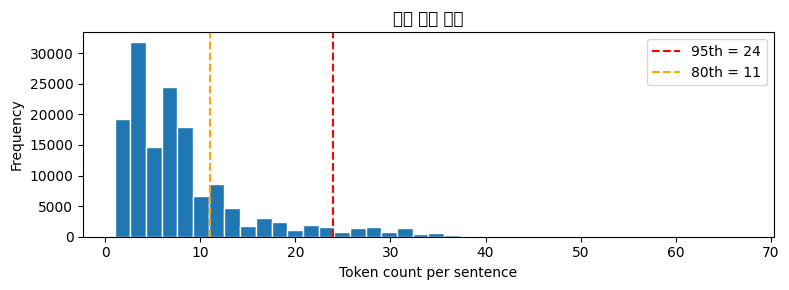

  → 선택된 MAX_LEN: 24


In [16]:
lengths = [len(s) for s in train_sents_pos]
p80 = int(np.percentile(lengths, 80))
p95 = int(np.percentile(lengths, 95))
print(f"\n[MAX_LEN 분석]")
print(f"  평균: {np.mean(lengths):.1f} | 중간값: {np.median(lengths):.1f}")
print(f"  80th percentile: {p80} | 95th percentile: {p95}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, edgecolor='white')
plt.axvline(p95, color='red',    linestyle='--', label=f'95th = {p95}')
plt.axvline(p80, color='orange', linestyle='--', label=f'80th = {p80}')
plt.xlabel('Token count per sentence')
plt.ylabel('Frequency')
plt.title('문장 길이 분포')
plt.legend()
plt.tight_layout()
plt.show()

# 데이터 분포에 맞춰 MAX_LEN 선택 (p95 기준)
OPT_MAX_LEN = p95
print(f"  → 선택된 MAX_LEN: {OPT_MAX_LEN}")

In [17]:
hist_exp4, model_exp4, tok_exp4 = run_experiment(
    name         = 'Exp4_MaxLen',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,           # [수정] 기존 20000 → 10000 유지 (변수 통제)
    max_len      = OPT_MAX_LEN,     # 이것만 변경
    build_fn     = build_bilstm_regularized,
    epochs       = 20
)


  실험: Exp4_MaxLen
  vocab_size=10000, max_len=24
  train_pad: (147737, 24), test_pad: (49240, 24)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7954 - loss: 0.4384 - val_accuracy: 0.8274 - val_loss: 0.3810
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8415 - loss: 0.3626 - val_accuracy: 0.8331 - val_loss: 0.3704
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8520 - loss: 0.3400 - val_accuracy: 0.8356 - val_loss: 0.3706
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8606 - loss: 0.3207 - val_accuracy: 0.8356 - val_loss: 0.3809
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8700 - loss: 0.3044 - val_accuracy: 0.8352 - val_loss: 0.3869
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8752 - loss: 0.2916 - val_accuracy: 0.8327 - val_loss: 0.4035
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8808 - loss: 0.2792 - val_accuracy: 0.8338 - val_loss: 0.4173
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8858 - loss: 0.2690 - va

In [18]:
callbacks_final = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,                    # [수정] 3 → 5 (여유 확보)
        mode='max',                    # [수정 6] 명시적으로 max 지정
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [19]:
hist_exp5, model_exp5, tok_exp5 = run_experiment(
    name         = 'Exp5_LRSchedule',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = OPT_MAX_LEN,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    callbacks    = callbacks_final
)


  실험: Exp5_LRSchedule
  vocab_size=10000, max_len=24
  train_pad: (147737, 24), test_pad: (49240, 24)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7919 - loss: 0.4411 - val_accuracy: 0.8315 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 2/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8414 - loss: 0.3641 - val_accuracy: 0.8345 - val_loss: 0.3693 - learning_rate: 0.0010
Epoch 3/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8524 - loss: 0.3387 - val_accuracy: 0.8371 - val_loss: 0.3715 - learning_rate: 0.0010
Epoch 4/30
920/924 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8576 - loss: 0.3278
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8606 - loss: 0.3215 - val_accuracy: 0.8376 - val_loss: 0.3790 - learning_rate: 0.0010
Epoch 5/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8726 - loss: 0.2958 - val_accuracy: 0.8370 - val_loss: 0.4024 - learning_rate: 5.0000e-04
Epoch 6/30
920/924 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8726 - lo

In [36]:
hist_exp6, model_exp6, tok_exp6 = run_experiment(
    name         = 'Exp6_Vocab',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,               # 10000 → 25000
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    callbacks    = callbacks_final
)


  실험: Exp6_Vocab
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.7866 - loss: 0.4481 - val_accuracy: 0.8311 - val_loss: 0.3775 - learning_rate: 0.0010
Epoch 2/30
922/924 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8442 - loss: 0.3642
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8493 - loss: 0.3536 - val_accuracy: 0.8369 - val_loss: 0.3694 - learning_rate: 0.0010
Epoch 3/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8693 - loss: 0.3128 - val_accuracy: 0.8409 - val_loss: 0.3749 - learning_rate: 5.0000e-04
Epoch 4/30
922/924 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8716 - loss: 0.3075
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
924/924 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8769 - loss: 0.2960 - val_accuracy: 0.8413 - val_loss: 0.3786 - learning_rate: 5.0000e-04
Epoch 5/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8866

In [44]:
hist_exp7, model_exp7, tok_exp7 = run_experiment(
    name         = 'Exp7_BatchSize',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    batch_size   = 64,
    callbacks    = callbacks_final
)


  실험: Exp7_BatchSize
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.7993 - loss: 0.4325 - val_accuracy: 0.8347 - val_loss: 0.3720 - learning_rate: 0.0010
Epoch 2/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8482 - loss: 0.3564
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8516 - loss: 0.3465 - val_accuracy: 0.8414 - val_loss: 0.3622 - learning_rate: 0.0010
Epoch 3/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8732 - loss: 0.3027 - val_accuracy: 0.8413 - val_loss: 0.3704 - learning_rate: 5.0000e-04
Epoch 4/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8756 - loss: 0.2965
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8810 - loss: 0.2860 - val_accuracy: 0.8416 - val_loss: 0.3806 - learning_rate: 5.0000e-04
Epoch 5/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - ac

In [47]:
hist_exp8, model_exp8, tok_exp8 = run_experiment(
    name         = 'Exp8_ValSplit',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    batch_size   = 64,
    callbacks    = callbacks_final,
    val_split    = 0.1
)


  실험: Exp8_ValSplit
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.8056 - loss: 0.4223 - val_accuracy: 0.8400 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 2/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8497 - loss: 0.3551
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.8531 - loss: 0.3457 - val_accuracy: 0.8422 - val_loss: 0.3623 - learning_rate: 0.0010
Epoch 3/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.8733 - loss: 0.3013 - val_accuracy: 0.8441 - val_loss: 0.3768 - learning_rate: 5.0000e-04
Epoch 4/30
2076/2078 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8773 - loss: 0.2950
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.8818 - loss: 0.2852 - val_accuracy: 0.8449 - val_loss: 0.3803 - learning_rate: 5.0000e-04
Epoch 5/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - ac

/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/2759110371.py:19: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.t

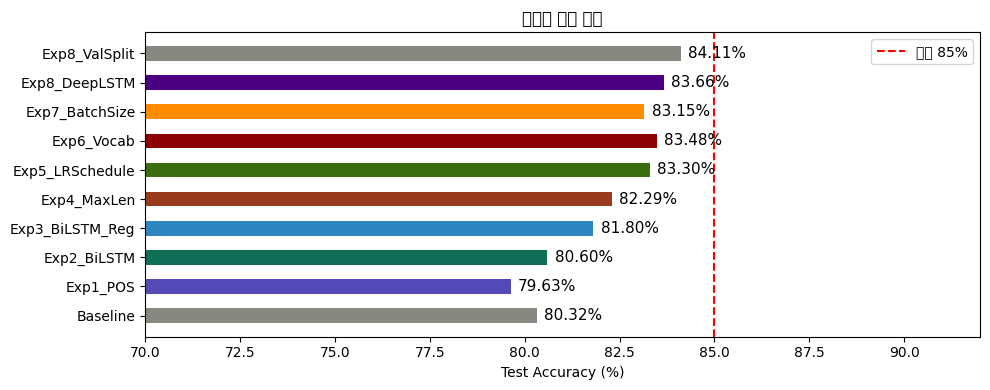

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(results.keys())
values = list(results.values())
colors = ['#888780', '#534AB7', '#0F6E56', '#2E86C1', '#993C1D',
          '#3B6D11', '#8B0000', '#FF8C00', '#4B0082']

bars = ax.barh(names, values, color=colors[:len(names)], height=0.5)
ax.axvline(x=85, color='red', linestyle='--', linewidth=1.5, label='목표 85%')
ax.set_xlabel('Test Accuracy (%)')   # [수정] val_accuracy → Test Accuracy
ax.set_title('실험별 성능 비교')
ax.set_xlim(70, 92)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_8326/1805355868.py:30: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8326/1805355868.py:30: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


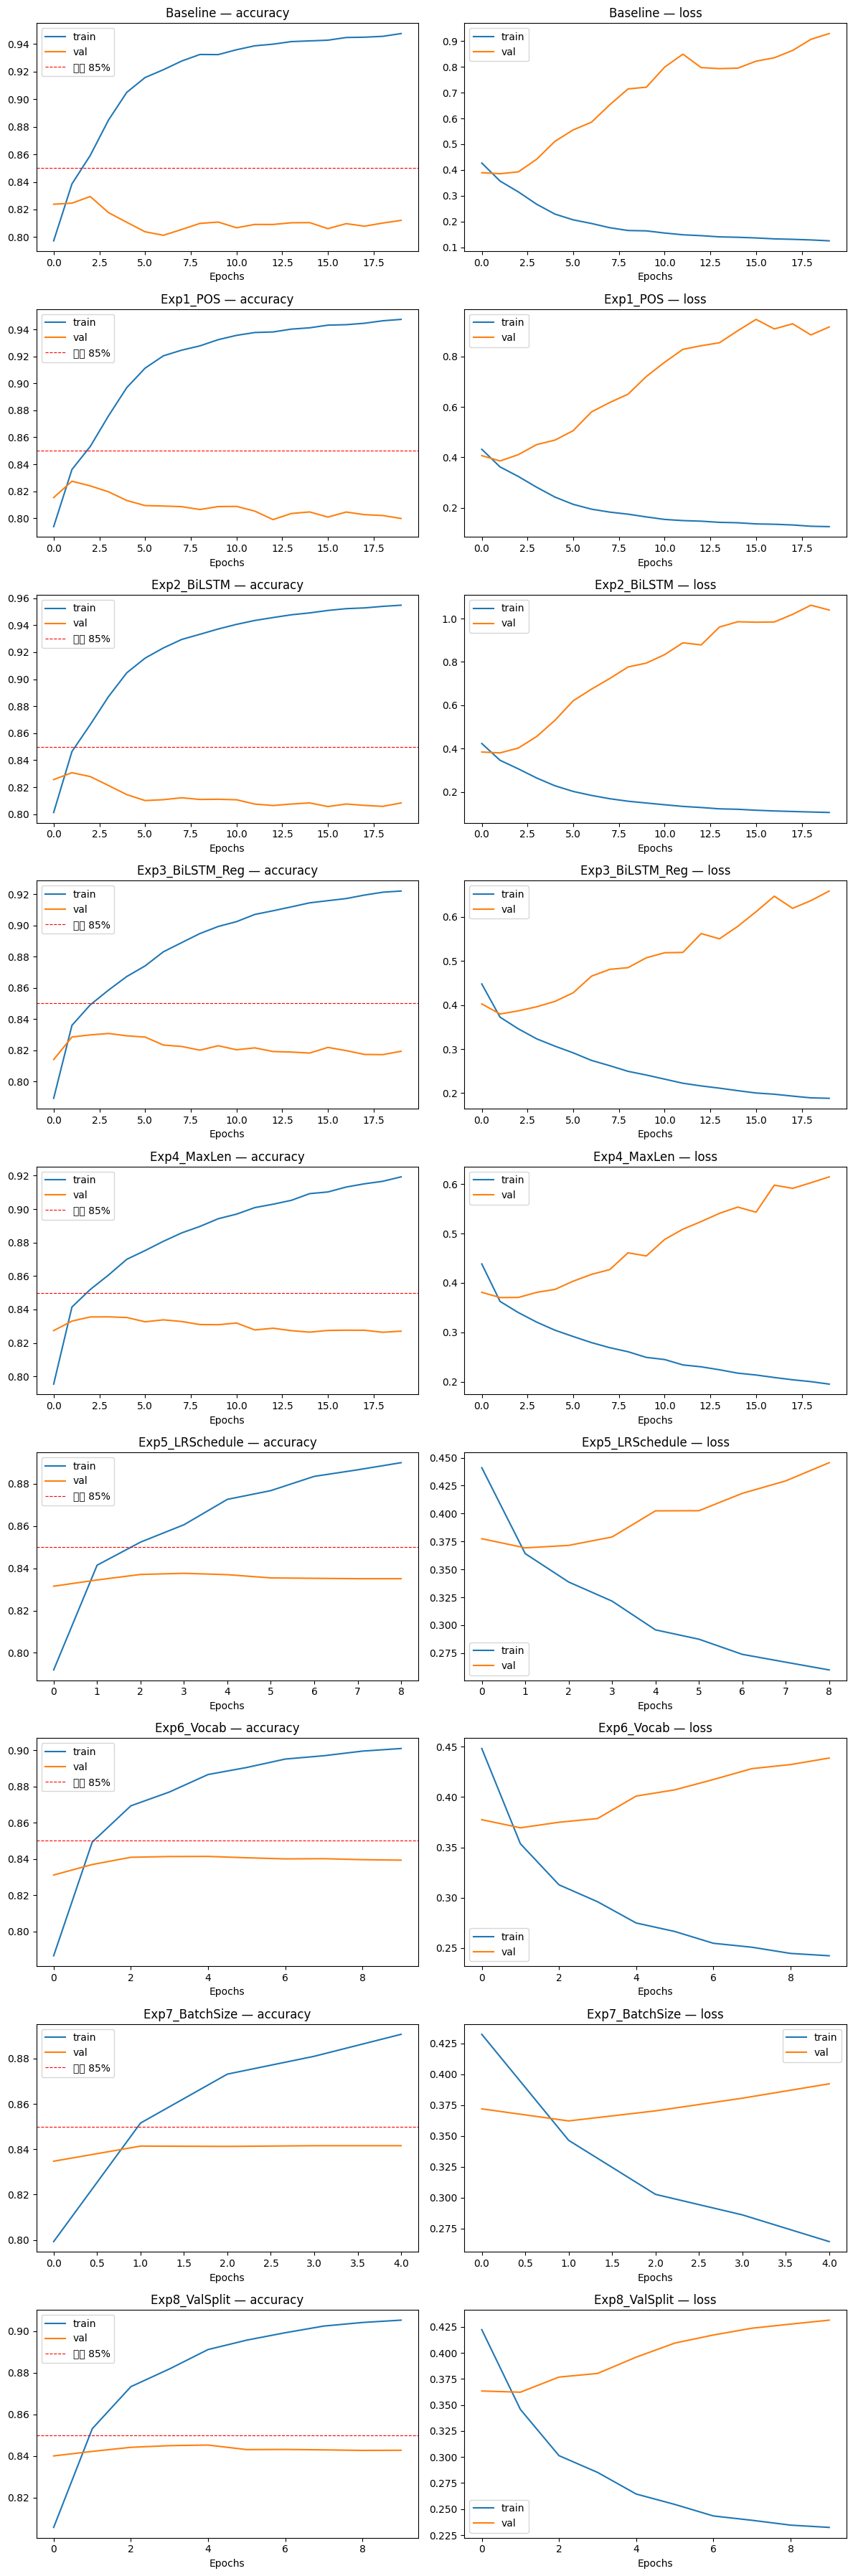


  실험명                    Test Accuracy
  Baseline                  80.32%  ██████
  Exp1_POS                  79.63%  ██████
  Exp2_BiLSTM               80.60%  ███████
  Exp3_BiLSTM_Reg           81.80%  ███████
  Exp4_MaxLen               82.29%  ████████
  Exp5_LRSchedule           83.30%  ████████
  Exp6_Vocab                83.48%  ████████
  Exp7_BatchSize            83.15%  ████████
  Exp8_DeepLSTM             83.66%  █████████
  Exp8_ValSplit             84.11%  █████████

[단계별 개선폭]
  Baseline → Exp1_POS: -0.69%
  Exp1_POS → Exp2_BiLSTM: +0.97%
  Exp2_BiLSTM → Exp3_BiLSTM_Reg: +1.20%
  Exp3_BiLSTM_Reg → Exp4_MaxLen: +0.49%
  Exp4_MaxLen → Exp5_LRSchedule: +1.01%
  Exp5_LRSchedule → Exp6_Vocab: +0.18%
  Exp6_Vocab → Exp7_BatchSize: -0.33%
  Exp7_BatchSize → Exp8_DeepLSTM: +0.51%
  Exp8_DeepLSTM → Exp8_ValSplit: +0.45%


In [49]:
histories = {
    'Baseline':         hist_base,
    'Exp1_POS':         hist_exp1,
    'Exp2_BiLSTM':      hist_exp2,
    'Exp3_BiLSTM_Reg':  hist_exp3,
    'Exp4_MaxLen':      hist_exp4,
    'Exp5_LRSchedule':  hist_exp5,
    'Exp6_Vocab':       hist_exp6,
    'Exp7_BatchSize':   hist_exp7,
    'Exp8_ValSplit':    hist_exp8,
}

fig, axes = plt.subplots(len(histories), 2,
                          figsize=(12, 4 * len(histories)))
for i, (name, hist) in enumerate(histories.items()):
    axes[i, 0].plot(hist.history['accuracy'],     label='train')
    axes[i, 0].plot(hist.history['val_accuracy'], label='val')
    axes[i, 0].axhline(0.85, color='red', linestyle='--',
                        linewidth=0.8, label='목표 85%')
    axes[i, 0].set_title(f'{name} — accuracy')
    axes[i, 0].set_xlabel('Epochs')
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['loss'],     label='train')
    axes[i, 1].plot(hist.history['val_loss'], label='val')
    axes[i, 1].set_title(f'{name} — loss')
    axes[i, 1].set_xlabel('Epochs')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


# 결과 테이블
print("\n" + "=" * 52)
print(f"  {'실험명':<22} {'Test Accuracy':>12}")
print("=" * 52)
for name, acc in results.items():
    bar    = '█' * int((acc - 70) / 1.5)
    target = '  ← 목표 달성!' if acc >= 85.0 else ''
    print(f"  {name:<22} {acc:>8.2f}%  {bar}{target}")
print("=" * 52)

# 단계별 개선폭
print("\n[단계별 개선폭]")
prev_name = None
for name, acc in results.items():
    if prev_name:
        diff = acc - results[prev_name]
        sign = '+' if diff >= 0 else ''
        print(f"  {prev_name} → {name}: {sign}{diff:.2f}%")
    prev_name = name

In [50]:
def predict_sentiment(text, model, tokenizer, max_len):
    tokens = preprocess_pos(text)
    seq    = tokenizer.texts_to_sequences([tokens])
    padded = pad_sequences(seq, maxlen=max_len,
                            padding='post', truncating='post')
    prob   = model.predict(padded, verbose=0)[0][0]
    label  = 'positive' if prob >= 0.5 else 'negative'
    print(f"  입력: {text}")
    print(f"  토큰: {tokens}")
    print(f"  결과: {label}  (확률: {prob:.4f})\n")
    return label

print("\n[최종 모델 예측 테스트]")
samples = [
    "이 영화 정말 재미있었어요. 배우들 연기가 너무 좋았어요",
    "시간 낭비였어요. 완전 실망했습니다",
    "그냥 그저 그랬어요. 기대보다는 별로",
    "역대급 명작입니다. 꼭 보세요",
    "스토리가 너무 허술해서 몰입이 안 됨"
]

for text in samples:
    predict_sentiment(text, model_exp8, tok_exp8, OPT_MAX_LEN)


[최종 모델 예측 테스트]
  입력: 이 영화 정말 재미있었어요. 배우들 연기가 너무 좋았어요
  토큰: ['영화', '정말', '재미있다', '배우', '연기', '너무', '좋다']
  결과: positive  (확률: 0.9929)

  입력: 시간 낭비였어요. 완전 실망했습니다
  토큰: ['시간', '낭비', '이다', '완전', '실망하다']
  결과: negative  (확률: 0.0004)

  입력: 그냥 그저 그랬어요. 기대보다는 별로
  토큰: ['그냥', '그저', '그렇다', '기대', '별로']
  결과: negative  (확률: 0.0041)

  입력: 역대급 명작입니다. 꼭 보세요
  토큰: ['역대', '명작', '이다', '보다']
  결과: positive  (확률: 0.9854)

  입력: 스토리가 너무 허술해서 몰입이 안 됨
  토큰: ['스토리', '너무', '허다', '하다', '몰입', '되다']
  결과: negative  (확률: 0.3275)

